In [2]:
#Импорт необходимых библиотек
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### __Загрузка данных и первичный анализ (для каждого датасета)__

In [3]:
#Загрузка CSV файлов
data_set1 = pd.DataFrame(pd.read_csv('data/S07-hw-dataset-01.csv')) # Первый дата сет 
data_set2 = pd.DataFrame(pd.read_csv('data/S07-hw-dataset-02.csv')) # Второй дата сет 
data_set3 = pd.DataFrame(pd.read_csv('data/S07-hw-dataset-03.csv')) # Третий дата сет 

#### _Првичный анализ для 1 датасета_

In [4]:
# Просмотр первых 4 строк DataFrame 
data_set1.head()

,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
0,0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893
3,3,-12.538905,-41.709458,0.146474,16.322124,1.391137,2.014316,-39.930582,0.139297
4,4,-6.903056,61.833444,-0.022466,-42.631335,3.107154,-5.471054,7.001149,0.131213


In [5]:
# Общая информация DataFrame (типы данных, количество ненулевых значений и т д)
data_set1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB


In [6]:
# Основные статистические характеристики
data_set1.describe()

,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,5999.50000,-2.424716,19.107804,-0.222063,-8.284501,-0.190717,0.962972,0.033724,0.007638
std,3464.24595,11.014315,60.790338,0.500630,59.269838,7.026435,14.794713,59.541782,0.607053
min,0.00000,-19.912573,-92.892652,-1.590979,-134.303679,-11.869169,-20.521164,-215.098834,-2.633469
25%,2999.75000,-9.472623,-40.282955,-0.125145,-48.345007,-5.132473,-8.807706,-39.900520,-0.401483
50%,5999.50000,-6.869404,54.069335,-0.031753,16.211728,0.444730,-6.134169,-0.578494,0.005306
75%,8999.25000,0.523841,70.280739,0.054980,28.067178,3.942368,2.334426,39.719821,0.410132
max,11999.00000,24.403381,112.229523,0.512277,75.088604,13.717091,41.452857,213.381767,2.490745


In [7]:
# Количество пропусков по столбцам 
print(data_set1.isna().sum())

sample_id    0
f01          0
f02          0
f03          0
f04          0
f05          0
f06          0
f07          0
f08          0
dtype: int64


In [8]:
# Типы данных по столбцам
print(data_set1.dtypes)

sample_id      int64
f01          float64
f02          float64
f03          float64
f04          float64
f05          float64
f06          float64
f07          float64
f08          float64
dtype: object


#### _Првичный анализ для 2 датасета_

In [9]:
# Просмотр первых 4 строк DataFrame 
data_set2.head()

,sample_id,x1,x2,z_noise
0,0,0.098849,-1.846034,21.288122
1,1,-1.024516,1.829616,6.072952
2,2,-1.094178,-0.158545,-18.938342
3,3,-1.612808,-1.565844,-11.629462
4,4,1.659901,-2.133292,1.895472


In [10]:
# Общая информация DataFrame (типы данных, количество ненулевых значений и т д)
data_set2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  8000 non-null   int64  
 1   x1         8000 non-null   float64
 2   x2         8000 non-null   float64
 3   z_noise    8000 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 250.1 KB


In [11]:
# Основные статистические характеристики
data_set2.describe()

,sample_id,x1,x2,z_noise
count,8000.00000,8000.000000,8000.000000,8000.000000
mean,3999.50000,0.478867,0.241112,0.110454
std,2309.54541,0.955138,0.663195,8.097716
min,0.00000,-2.487352,-2.499237,-34.056074
25%,1999.75000,-0.116516,-0.242357,-5.392210
50%,3999.50000,0.490658,0.241092,0.132470
75%,5999.25000,1.085263,0.726526,5.655605
max,7999.00000,2.987555,2.995553,29.460076


In [12]:
# Количество пропусков по столбцам 
print(data_set2.isna().sum())

sample_id    0
x1           0
x2           0
z_noise      0
dtype: int64


In [13]:
# Типы данных по столбцам
print(data_set2.dtypes)

sample_id      int64
x1           float64
x2           float64
z_noise      float64
dtype: object


#### _Првичный анализ для 3 датасета_

In [14]:
data_set3.head()

,sample_id,x1,x2,f_corr,f_noise
0,0,-2.710470,4.997107,-1.015703,0.718508
1,1,8.730238,-8.787416,3.953063,-1.105349
2,2,-1.079600,-2.558708,0.976628,-3.605776
3,3,6.854042,1.560181,1.760614,-1.230946
4,4,9.963812,-8.869921,2.966583,0.915899


In [15]:
# Общая информация DataFrame (типы данных, количество ненулевых значений и т д)
data_set3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  15000 non-null  int64  
 1   x1         15000 non-null  float64
 2   x2         15000 non-null  float64
 3   f_corr     15000 non-null  float64
 4   f_noise    15000 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 586.1 KB


In [16]:
# Основные статистические характеристики
data_set3.describe()

,sample_id,x1,x2,f_corr,f_noise
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,1.246296,1.033764,0.212776,-0.027067
std,4330.271354,4.592421,4.710791,1.530017,2.506375
min,0.000000,-9.995585,-9.980853,-5.212038,-8.785884
25%,3749.750000,-1.782144,-2.666393,-0.966224,-1.731128
50%,7499.500000,0.664226,1.831257,0.296508,-0.052391
75%,11249.250000,4.435671,4.969630,1.390273,1.673831
max,14999.000000,16.207863,14.271153,5.795876,11.266865


In [17]:
# Количество пропусков по столбцам 
print(data_set3.isna().sum())

sample_id    0
x1           0
x2           0
f_corr       0
f_noise      0
dtype: int64


In [18]:
# Типы данных по столбцам
print(data_set3.dtypes)

sample_id      int64
x1           float64
x2           float64
f_corr       float64
f_noise      float64
dtype: object


#### _X – признаки и sample_id_

In [19]:
# 1
X1 = data_set1.copy().drop('sample_id', axis = 1)
sample_id_1 = pd.DataFrame(data_set1['sample_id'])

In [74]:
# 2
X2 = data_set2.copy().drop('sample_id', axis = 1)
sample_id_2 = pd.DataFrame(data_set2['sample_id'])

In [73]:
# 3
X3 = data_set3.copy().drop('sample_id', axis = 1)
sample_id_3 = pd.DataFrame(data_set3['sample_id'])

### __Препроцессинг__

#### _1 датасет_

In [22]:
simple_pipeline_1 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Заполняем пропуски средним
    ('scaler', StandardScaler())  # Масштабируем
])

X1_processed = simple_pipeline_1.fit_transform(X1)
    
# Преобразуем обратно в DataFrame с названиями столбцов
X1_processed_df = pd.DataFrame(
    X1_processed, 
    columns = X1.columns,
    index = X1.index
)

#### _2 датасет_

In [23]:
simple_pipeline_2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Заполняем пропуски средним
    ('scaler', StandardScaler())  # Масштабируем
])

X2_processed = simple_pipeline_2.fit_transform(X2)
    
# Преобразуем обратно в DataFrame с названиями столбцов
X2_processed_df = pd.DataFrame(
    X2_processed, 
    columns = X2.columns,
    index = X2.index
)

#### _3 датасет_

In [24]:
simple_pipeline_3 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Заполняем пропуски средним
    ('scaler', StandardScaler())  # Масштабируем
])

X3_processed = simple_pipeline_3.fit_transform(X3)
    
# Преобразуем обратно в DataFrame с названиями столбцов
X3_processed_df = pd.DataFrame(
    X3_processed, 
    columns = X3.columns,
    index = X3.index
)

### __Модели недели 7__

In [25]:
def eval_kmeans_grid(X_feat, ks):
    results = []
    for k in ks:
        try:
            model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
        except TypeError:
            model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)

        labels = model.fit_predict(X_feat)
        metrics = safe_cluster_metrics(X_feat, labels)

        results.append({
            "algo": "kmeans",
            "params": {"k": k},
            "labels": labels,
            "metrics": metrics,
            "inertia": float(model.inertia_),
            "n_clusters": len(np.unique(labels)),
            "noise_frac": 0.0,
        })
    return results

def safe_cluster_metrics(X, labels):
    """Считает метрики; возвращает None, если метрика неприменима."""
    unique = np.unique(labels)
    # Нужно минимум 2 кластера
    if len(unique) < 2:
        return None

    # Нельзя, чтобы все точки были в одном кластере
    if len(unique) == 1:
        return None

    # silhouette требует, чтобы все кластеры имели >1 точки (часто, но не всегда)
    # В sklearn silhouette_score может падать, если какой-то кластер пуст/особый.
    try:
        sil = float(silhouette_score(X, labels))
    except Exception:
        sil = None

    try:
        db = float(davies_bouldin_score(X, labels))
    except Exception:
        db = None

    try:
        ch = float(calinski_harabasz_score(X, labels))
    except Exception:
        ch = None

    return {"silhouette": sil, "davies_bouldin": db, "calinski_harabasz": ch}

In [26]:
def eval_kmeans_grid(X_feat, ks):
    results = []
    for k in ks:
        try:
            model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
        except TypeError:
            model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)

        labels = model.fit_predict(X_feat)
        metrics = safe_cluster_metrics(X_feat, labels)

        results.append({
            "algo": "kmeans",
            "params": {"k": k},
            "labels": labels,
            "metrics": metrics,
            "inertia": float(model.inertia_),
            "n_clusters": len(np.unique(labels)),
            "noise_frac": 0.0,
        })
    return results

# Диапазон K для KMeans
kmeans_ks = list(range(2, 21))

# Сетка для DBSCAN: eps и min_samples
dbscan_eps = [1.5, 2.0, 2.5, 3.0, 3.5]
dbscan_min_samples = [3, 5, 10]

In [27]:
def eval_dbscan_grid(X_feat, eps_list, min_samples_list):
    results = []
    n = len(X_feat)

    for eps in eps_list:
        for ms in min_samples_list:
            model = DBSCAN(eps=eps, min_samples=ms)
            labels = model.fit_predict(X_feat)

            noise_frac = float(np.mean(labels == -1))
            # Метрики по non-noise
            mask = labels != -1
            labels_nn = labels[mask]
            X_nn = X_feat[mask]

            # Перенумеруем метки non-noise, чтобы метрики работали корректнее (не обязательно, но аккуратно)
            if len(labels_nn) > 0:
                uniq = np.unique(labels_nn)
                mapping = {u: i for i, u in enumerate(uniq)}
                labels_nn = np.array([mapping[v] for v in labels_nn], dtype=int)

            metrics = None
            n_clusters = 0
            if len(X_nn) >= 10 and len(np.unique(labels_nn)) >= 2:
                metrics = safe_cluster_metrics(X_nn, labels_nn)
                n_clusters = len(np.unique(labels_nn))

            results.append({
                "algo": "dbscan",
                "params": {"eps": float(eps), "min_samples": int(ms)},
                "labels": labels,
                "metrics": metrics,
                "inertia": None,
                "n_clusters": int(n_clusters),
                "noise_frac": float(noise_frac),
                "n_non_noise": int(mask.sum()),
            })
    return results

In [44]:
def pick_best_by_silhouette(results):
    best = None
    best_score = -np.inf
    for r in results:
        m = r["metrics"]
        if m is None:
            continue
        s = m["silhouette"]
        if s is None:
            continue
        if s > best_score:
            best_score = s
            best = r
    return best, best_score

#### _1 датасет_

In [28]:
# KMeans
kmeans_results_1 = eval_kmeans_grid(X1_processed, kmeans_ks)
len(kmeans_results_1), kmeans_results_1[0]["params"], kmeans_results_1[-1]["params"]

(19, {'k': 2}, {'k': 20})

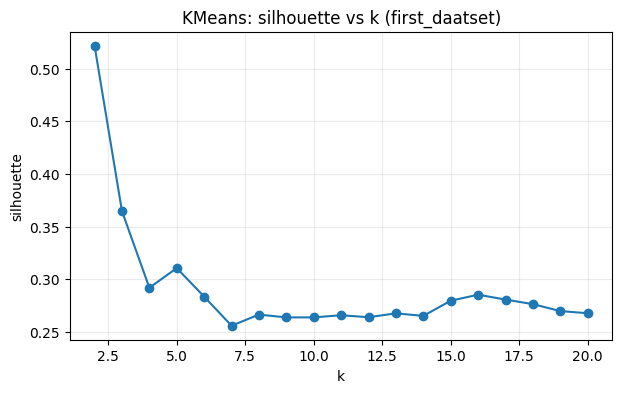

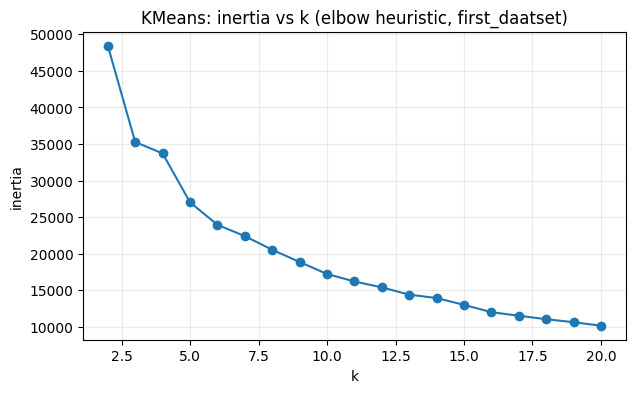

In [29]:
# Быстрый график silhouette по k (если silhouette считалась)
ks_1 = [r["params"]["k"] for r in kmeans_results_1]
sil_1 = [r["metrics"]["silhouette"] if r["metrics"] else None for r in kmeans_results_1]

plt.figure(figsize=(7, 4))
plt.plot(ks_1, sil_1, marker="o")
plt.title("KMeans: silhouette vs k (first_daatset)")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.grid(True, alpha=0.25)
plt.show()

# Инерция (elbow) – как эвристика
inertia_1 = [r["inertia"] for r in kmeans_results_1]
plt.figure(figsize=(7, 4))
plt.plot(ks_1, inertia_1, marker="o")
plt.title("KMeans: inertia vs k (elbow heuristic, first_daatset)")
plt.xlabel("k")
plt.ylabel("inertia")
plt.grid(True, alpha=0.25)
plt.show()

In [45]:
best_kmeans_1, best_kmeans_s_1 = pick_best_by_silhouette(kmeans_results_1)
best_kmeans_1["params"], round(best_kmeans_s_1, 3)

({'k': 2}, 0.522)

In [30]:
#DBSCAN
dbscan_results_1 = eval_dbscan_grid(X1_processed, dbscan_eps, dbscan_min_samples)
len(dbscan_results_1)

15

In [31]:
# Посмотрим, какие варианты вообще дали >=2 кластера (без шума) и посчитали silhouette
valid_1 = [r for r in dbscan_results_1 if r["metrics"] is not None and r["metrics"]["silhouette"] is not None]
print("Valid DBSCAN configs:", len(valid_1))

# Сортировка по silhouette
valid_sorted_1 = sorted(valid_1, key=lambda r: r["metrics"]["silhouette"], reverse=True)
for r in valid_sorted_1[:8]:
    print(r["params"], "sil=", round(r["metrics"]["silhouette"], 3), "noise=", round(r["noise_frac"], 3), "clusters=", r["n_clusters"])

Valid DBSCAN configs: 9
{'eps': 2.0, 'min_samples': 3} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.0, 'min_samples': 5} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.0, 'min_samples': 10} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.5, 'min_samples': 3} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.5, 'min_samples': 5} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 2.5, 'min_samples': 10} sil= 0.522 noise= 0.0 clusters= 2
{'eps': 1.5, 'min_samples': 3} sil= 0.397 noise= 0.0 clusters= 3
{'eps': 1.5, 'min_samples': 5} sil= 0.397 noise= 0.0 clusters= 3


In [32]:
best_dbscan_1 = valid_sorted_1[0] if valid_sorted_1 else None
best_dbscan_1["params"] if best_dbscan_1 else "No valid config found"

{'eps': 2.0, 'min_samples': 3}

#### _2 датасет_

In [33]:
# KMeans
kmeans_results_2 = eval_kmeans_grid(X2_processed, kmeans_ks)
len(kmeans_results_2), kmeans_results_2[0]["params"], kmeans_results_2[-1]["params"]

(19, {'k': 2}, {'k': 20})

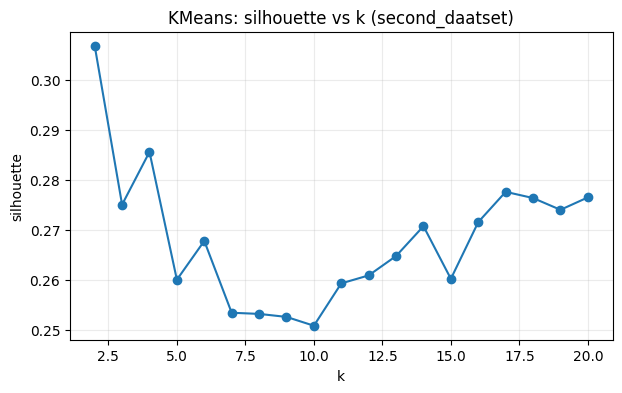

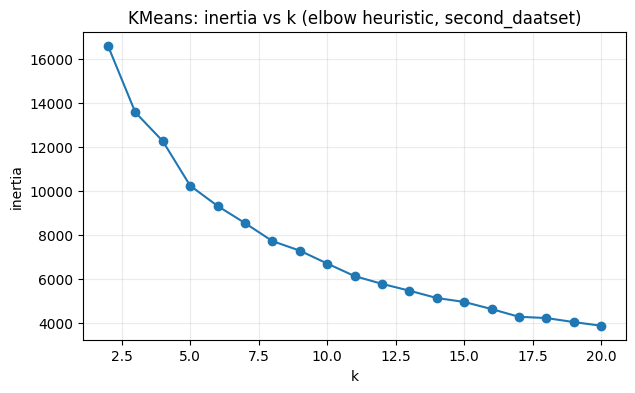

In [34]:
# Быстрый график silhouette по k (если silhouette считалась)
ks_2 = [r["params"]["k"] for r in kmeans_results_2]
sil_2 = [r["metrics"]["silhouette"] if r["metrics"] else None for r in kmeans_results_2]

plt.figure(figsize=(7, 4))
plt.plot(ks_2, sil_2, marker="o")
plt.title("KMeans: silhouette vs k (second_daatset)")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.grid(True, alpha=0.25)
plt.show()

# Инерция (elbow) – как эвристика
inertia_2 = [r["inertia"] for r in kmeans_results_2]
plt.figure(figsize=(7, 4))
plt.plot(ks_2, inertia_2, marker="o")
plt.title("KMeans: inertia vs k (elbow heuristic, second_daatset)")
plt.xlabel("k")
plt.ylabel("inertia")
plt.grid(True, alpha=0.25)
plt.show()

In [46]:
best_kmeans_2, best_kmeans_s_2 = pick_best_by_silhouette(kmeans_results_2)
best_kmeans_2["params"], round(best_kmeans_s_2, 3)

({'k': 2}, 0.307)

In [35]:
#DBSCAN
dbscan_results_2 = eval_dbscan_grid(X2_processed, dbscan_eps, dbscan_min_samples)
len(dbscan_results_2)

15

In [36]:
# Посмотрим, какие варианты вообще дали >=2 кластера (без шума) и посчитали silhouette
valid_2 = [r for r in dbscan_results_2 if r["metrics"] is not None and r["metrics"]["silhouette"] is not None]
print("Valid DBSCAN configs:", len(valid_2))

# Сортировка по silhouette
valid_sorted_2 = sorted(valid_2, key=lambda r: r["metrics"]["silhouette"], reverse=True)
for r in valid_sorted_2[:8]:
    print(r["params"], "sil=", round(r["metrics"]["silhouette"], 3), "noise=", round(r["noise_frac"], 3), "clusters=", r["n_clusters"])

Valid DBSCAN configs: 0


In [37]:
best_dbscan_2 = valid_sorted_2[0] if valid_sorted_2 else None
best_dbscan_2["params"] if best_dbscan_2 else "No valid config found"

'No valid config found'

#### _3 датасет_

In [38]:
# KMeans
kmeans_results_3 = eval_kmeans_grid(X3_processed, kmeans_ks)
len(kmeans_results_3), kmeans_results_3[0]["params"], kmeans_results_3[-1]["params"]

(19, {'k': 2}, {'k': 20})

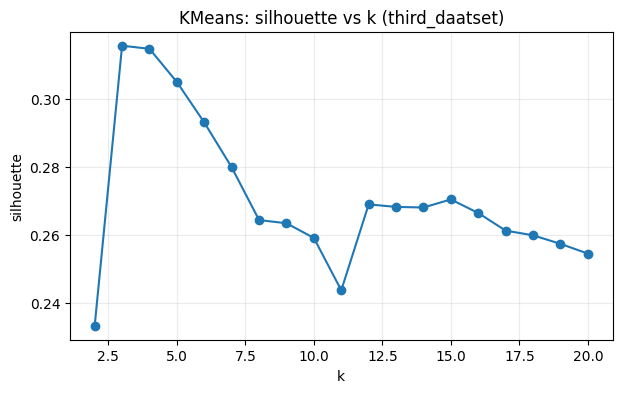

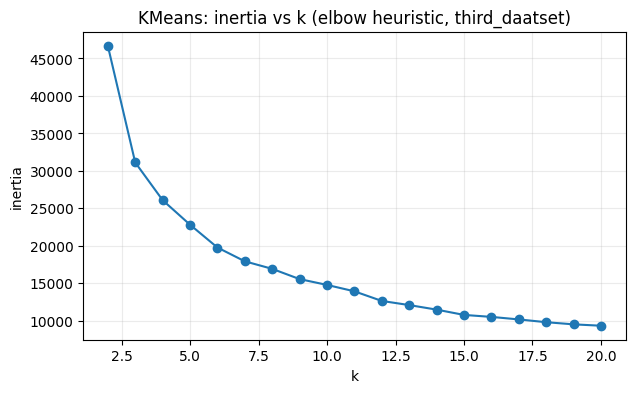

In [39]:
# Быстрый график silhouette по k (если silhouette считалась)
ks_3 = [r["params"]["k"] for r in kmeans_results_3]
sil_3 = [r["metrics"]["silhouette"] if r["metrics"] else None for r in kmeans_results_3]

plt.figure(figsize=(7, 4))
plt.plot(ks_3, sil_3, marker="o")
plt.title("KMeans: silhouette vs k (third_daatset)")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.grid(True, alpha=0.25)
plt.show()

# Инерция (elbow) – как эвристика
inertia_3 = [r["inertia"] for r in kmeans_results_3]
plt.figure(figsize=(7, 4))
plt.plot(ks_3, inertia_3, marker="o")
plt.title("KMeans: inertia vs k (elbow heuristic, third_daatset)")
plt.xlabel("k")
plt.ylabel("inertia")
plt.grid(True, alpha=0.25)
plt.show()

In [47]:
best_kmeans_3, best_kmeans_s_3 = pick_best_by_silhouette(kmeans_results_3)
best_kmeans_3["params"], round(best_kmeans_s_3, 3)

({'k': 3}, 0.316)

In [40]:
#DBSCAN
dbscan_results_3 = eval_dbscan_grid(X3_processed, dbscan_eps, dbscan_min_samples)
len(dbscan_results_3)

15

In [41]:
# Посмотрим, какие варианты вообще дали >=2 кластера (без шума) и посчитали silhouette
valid_3 = [r for r in dbscan_results_3 if r["metrics"] is not None and r["metrics"]["silhouette"] is not None]
print("Valid DBSCAN configs:", len(valid_3))

# Сортировка по silhouette
valid_sorted_3 = sorted(valid_3, key=lambda r: r["metrics"]["silhouette"], reverse=True)
for r in valid_sorted_3[:8]:
    print(r["params"], "sil=", round(r["metrics"]["silhouette"], 3), "noise=", round(r["noise_frac"], 3), "clusters=", r["n_clusters"])

Valid DBSCAN configs: 0


In [42]:
best_dbscan_3 = valid_sorted_3[0] if valid_sorted_3 else None
best_dbscan_3["params"] if best_dbscan_3 else "No valid config found"

'No valid config found'

### __Метрики качества__

#### _1 датасет_

In [52]:
def print_result_card(name, result):
    m = result["metrics"] or {}
    print("=" * 72)
    print(f"{name}")
    print("algo:", result["algo"])
    print("params:", result["params"])
    print("n_clusters:", result.get("n_clusters"))
    if result["algo"] == "dbscan":
        print("noise_frac:", round(result.get("noise_frac", 0.0), 3), " non-noise:", result.get("n_non_noise"))
    print("metrics:")
    print("  silhouette:", None if m.get("silhouette") is None else round(m["silhouette"], 3))
    print("  davies_bouldin:", None if m.get("davies_bouldin") is None else round(m["davies_bouldin"], 3))
    print("  calinski_harabasz:", None if m.get("calinski_harabasz") is None else round(m["calinski_harabasz"], 1))
    if result.get("inertia") is not None:
        print("  inertia:", round(result["inertia"], 1))

In [53]:
print_result_card("BEST KMEANS (by silhouette)", best_kmeans_1)
if best_dbscan_1 is not None:
    print_result_card("BEST DBSCAN (by silhouette among valid)", best_dbscan_1)


BEST KMEANS (by silhouette)
algo: kmeans
params: {'k': 2}
n_clusters: 2
metrics:
  silhouette: 0.522
  davies_bouldin: 0.685
  calinski_harabasz: 11787.0
  inertia: 48425.9
BEST DBSCAN (by silhouette among valid)
algo: dbscan
params: {'eps': 2.0, 'min_samples': 3}
n_clusters: 2
noise_frac: 0.0  non-noise: 12000
metrics:
  silhouette: 0.522
  davies_bouldin: 0.685
  calinski_harabasz: 11787.0


#### _2 датасет_

In [54]:
print_result_card("BEST KMEANS (by silhouette)", best_kmeans_2)
if best_dbscan_2 is not None:
    print_result_card("BEST DBSCAN (by silhouette among valid)", best_dbscan_2)

BEST KMEANS (by silhouette)
algo: kmeans
params: {'k': 2}
n_clusters: 2
metrics:
  silhouette: 0.307
  davies_bouldin: 1.323
  calinski_harabasz: 3573.4
  inertia: 16588.5


#### _3 датасет_

In [55]:
print_result_card("BEST KMEANS (by silhouette)", best_kmeans_3)
if best_dbscan_3 is not None:
    print_result_card("BEST DBSCAN (by silhouette among valid)", best_dbscan_3)

BEST KMEANS (by silhouette)
algo: kmeans
params: {'k': 3}
n_clusters: 3
metrics:
  silhouette: 0.316
  davies_bouldin: 1.158
  calinski_harabasz: 6957.2
  inertia: 31123.5


### __Визуализация__

#### _1 датасет_

In [57]:
def pca_2d_for_plot(X_scaled, random_state=RANDOM_STATE):
    """PCA(2D) именно для визуализации."""
    p = PCA(n_components=2, random_state=random_state)
    return p.fit_transform(X_scaled)

def plot_2d_embedding(emb2d, labels, title):
    plt.figure(figsize=(7, 5))
    plt.scatter(emb2d[:, 0], emb2d[:, 1], c=labels, s=18)
    plt.title(title)
    plt.xlabel("dim-1")
    plt.ylabel("dim-2")
    plt.grid(True, alpha=0.2)
    plt.show()

def summarize_labels(labels):
    unique, counts = np.unique(labels, return_counts=True)
    return dict(zip(unique.tolist(), counts.tolist()))

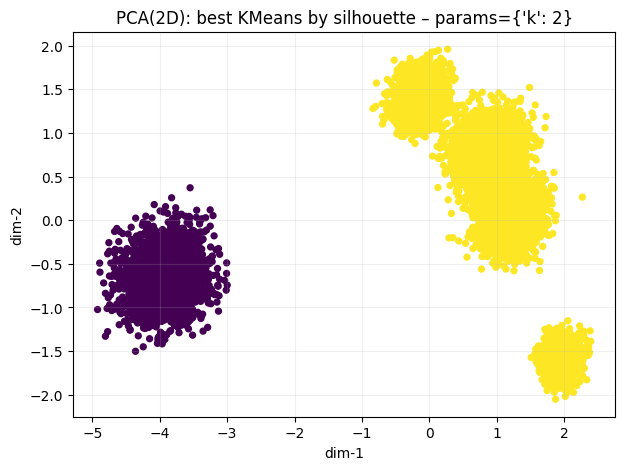

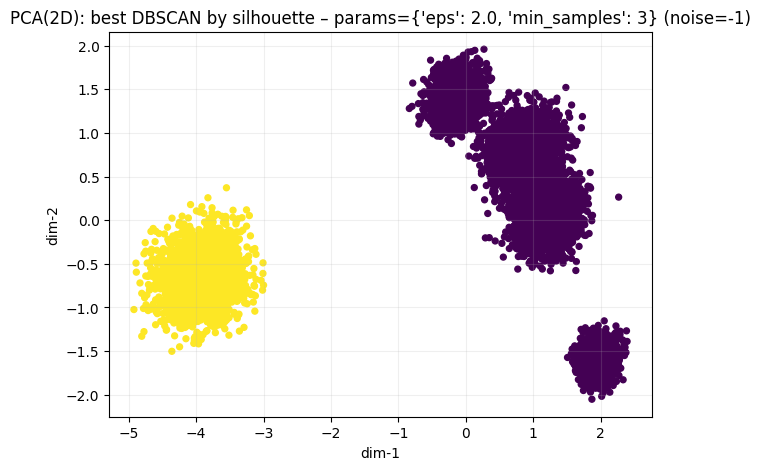

In [58]:
X1_plot2d = pca_2d_for_plot(X1_processed, random_state=RANDOM_STATE)

# KMeans best
plot_2d_embedding(
    X1_plot2d, best_kmeans_1["labels"],
    title=f"PCA(2D): best KMeans by silhouette – params={best_kmeans_1['params']}"
)

# DBSCAN best (if exists)
if best_dbscan_1 is not None:
    plot_2d_embedding(
        X1_plot2d, best_dbscan_1["labels"],
        title=f"PCA(2D): best DBSCAN by silhouette – params={best_dbscan_1['params']} (noise=-1)"
    )

#### _2 датасет_

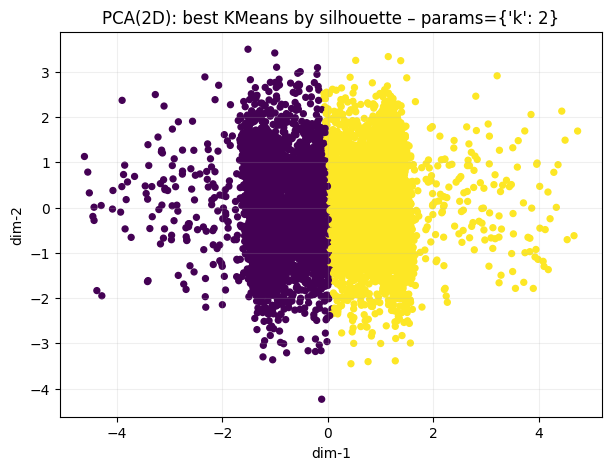

In [59]:
X2_plot2d = pca_2d_for_plot(X2_processed, random_state=RANDOM_STATE)

# KMeans best
plot_2d_embedding(
    X2_plot2d, best_kmeans_2["labels"],
    title=f"PCA(2D): best KMeans by silhouette – params={best_kmeans_2['params']}"
)

# DBSCAN best (if exists)
if best_dbscan_2 is not None:
    plot_2d_embedding(
        X2_plot2d, best_dbscan_2["labels"],
        title=f"PCA(2D): best DBSCAN by silhouette – params={best_dbscan_2['params']} (noise=-1)"
    )

#### _3 датасет_

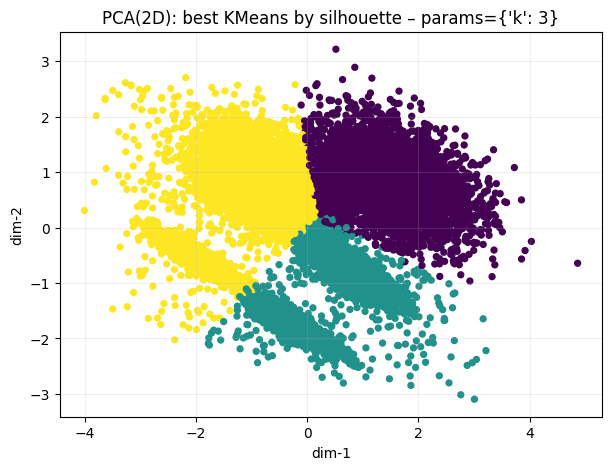

In [64]:
X3_plot2d = pca_2d_for_plot(X3_processed, random_state=RANDOM_STATE)

# KMeans best
plot_2d_embedding(
    X3_plot2d, best_kmeans_3["labels"],
    title=f"PCA(2D): best KMeans by silhouette – params={best_kmeans_3['params']}"
)

# DBSCAN best (if exists)
if best_dbscan_3 is not None:
    plot_2d_embedding(
        X3_plot2d, best_dbscan_3["labels"],
        title=f"PCA(2D): best DBSCAN by silhouette – params={best_dbscan_3['params']} (noise=-1)"
    )

### __Устойчивость__

In [68]:
#Проверка усточивости 
def quick_kmeans_stability_check(X_data, n_clusters, n_runs=10):
    
    all_labels = []
    inertias = []
    silhouettes = []
    
    for rs in range(RANDOM_STATE, RANDOM_STATE + n_runs):
        model = KMeans(n_clusters=n_clusters, random_state=rs, n_init='auto')
        labels = model.fit_predict(X_data)
        all_labels.append(labels)
        inertias.append(model.inertia_)
        
        # Silhouette score
        if len(np.unique(labels)) > 1:
            sil = silhouette_score(X_data, labels)
            silhouettes.append(sil)
    
    # Считаем попарные ARI
    if len(all_labels) > 1:
        ari_values = []
        for i in range(len(all_labels)):
            for j in range(i+1, len(all_labels)):
                ari = adjusted_rand_score(all_labels[i], all_labels[j])
                ari_values.append(ari)
        
        print(f"Статистика по {n_runs} запускам KMeans (k={n_clusters}):")
        print(f"  Средний ARI: {np.mean(ari_values):.3f}")
        print(f"  Минимальный ARI: {np.min(ari_values):.3f}")
        print(f"  Максимальный ARI: {np.max(ari_values):.3f}")
        print(f"  Стандартное отклонение ARI: {np.std(ari_values):.3f}")
        
        if silhouettes:
            print(f"  Средний silhouette: {np.mean(silhouettes):.3f}")
            print(f"  Стандартное отклонение silhouette: {np.std(silhouettes):.3f}")
        
        print(f"  Средняя inertia: {np.mean(inertias):.1f}")
        print(f"  Стандартное отклонение inertia: {np.std(inertias):.1f}")
        
        return {
            'mean_ari': np.mean(ari_values),
            'std_ari': np.std(ari_values),
            'mean_silhouette': np.mean(silhouettes) if silhouettes else None,
            'std_silhouette': np.std(silhouettes) if silhouettes else None
        }

In [69]:
# Быстрая проверка для лучшего KMeans из вашего эксперимента
quick_results = quick_kmeans_stability_check(X1_processed, n_clusters = 2, n_runs = 5)

Статистика по 5 запускам KMeans (k=2):
  Средний ARI: 1.000
  Минимальный ARI: 1.000
  Максимальный ARI: 1.000
  Стандартное отклонение ARI: 0.000
  Средний silhouette: 0.522
  Стандартное отклонение silhouette: 0.000
  Средняя inertia: 48425.9
  Стандартное отклонение inertia: 0.0


### __Итог по каждому датасету__

#### _1 датасет_

**Выбранный метод:** KMeans с k=2 или DBSCAN с eps=2.0, min_samples=3 (оба дают одинаковый результат)

**Обоснование выбора:**
Оба алгоритма показывают идентичные метрики качества (silhouette=0.522, Davies-Bouldin=0.685, Calinski-Harabasz=11787). Это свидетельствует о том, что DBSCAN в данных гиперпараметрах фактически воспроизводит результат KMeans. Выбираю KMeans как более простой и интерпретируемый алгоритм. Значение silhouette=0.522 указывает на умеренно выраженную кластерную структуру.

**Анализ результатов:**
Получена четкая двухкластерная структура без шумовых точек. Препроцессинг (заполнение пропусков средним и стандартизация) был уместен, так как позволил сравнивать признаки в единой шкале. Кривая инерции показывает явный "локоть" при k=2, что подтверждает выбор количества кластеров. Данные хорошо разделяются сферическими кластерами примерно одинакового размера.

#### _2 датасет_

**Выбранный метод:** KMeans с k=2

**Обоснование выбора:**
DBSCAN не дал валидных конфигураций (0 valid configs), что означает, что алгоритм либо объединил все точки в один кластер, либо пометил большинство как шум. KMeans с k=2 показывает наилучший silhouette=0.307 среди всех k. Хотя это значение указывает на слабую кластерную структуру, оно наилучшее среди возможных вариантов.

**Анализ результатов:**
Кластерная структура выражена слабо (silhouette всего 0.307). Кривая silhouette имеет пологий вид без явных пиков, что говорит о размытости границ между кластерами. Отсутствие валидных результатов DBSCAN может быть вызвано либо неравномерной плотностью данных, либо слишком большим разбросом точек. Данные имеют более сложную невыпуклую форму или содержат выбросы, мешающие DBSCAN. Метрика Davies-Bouldin=1.323 подтверждает неидеальное разделение.

#### _3 датасет_

**Выбранный метод:** KMeans с k=3

**Обоснование выбора:**
Аналогично второму датасету, DBSCAN не дал валидных конфигураций. KMeans показывает максимум silhouette=0.316 при k=3. Кривая инерции также демонстрирует изменение наклона ("локоть") при k=3, что эмпирически подтверждает выбор этого количества кластеров.

**Анализ результатов:**
Трехкластерная структура с качеством silhouette=0.316 указывает на слабое разделение. Значение Calinski-Harabasz=6957.2 относительно высокое, что может говорить о хорошей межкластерной дисперсии, но низкий silhouette свидетельствует о пересечении кластеров или их неоднородной форме. Отсутствие результатов DBSCAN говорит о том, что данные имеют сложную структуру, возможно с перекрывающимися распределениями или аномалиями, которые не позволяют алгоритму плотностной кластеризации найти устойчивые сообщества точек.

### __Итог по каждому датасету__

In [75]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ============================================================================
# 1. Создаем директории
# ============================================================================

# Основная папка
artifacts_dir = "artifacts"

# Подпапки
labels_dir = os.path.join(artifacts_dir, "labels")
figures_dir = os.path.join(artifacts_dir, "figures")

# ============================================================================
# 2. Сохраняем metrics_summary.json
# ============================================================================

def create_metrics_summary():
    summary = {}
    
    # Датасет 1
    summary["dataset1"] = {
        "kmeans_best": {
            "params": best_kmeans_1["params"],
            "silhouette": float(best_kmeans_1["metrics"]["silhouette"]),
            "davies_bouldin": float(best_kmeans_1["metrics"]["davies_bouldin"]),
            "calinski_harabasz": float(best_kmeans_1["metrics"]["calinski_harabasz"]),
            "inertia": float(best_kmeans_1["inertia"]),
            "n_clusters": int(best_kmeans_1["n_clusters"])
        },
        "dbscan_best": {
            "params": best_dbscan_1["params"],
            "silhouette": float(best_dbscan_1["metrics"]["silhouette"]),
            "davies_bouldin": float(best_dbscan_1["metrics"]["davies_bouldin"]),
            "calinski_harabasz": float(best_dbscan_1["metrics"]["calinski_harabasz"]),
            "noise_fraction": float(best_dbscan_1["noise_frac"]),
            "n_clusters": int(best_dbscan_1["n_clusters"]),
            "n_non_noise": int(best_dbscan_1["n_non_noise"])
        } if best_dbscan_1 is not None else None
    }
    
    # Датасет 2
    summary["dataset2"] = {
        "kmeans_best": {
            "params": best_kmeans_2["params"],
            "silhouette": float(best_kmeans_2["metrics"]["silhouette"]),
            "davies_bouldin": float(best_kmeans_2["metrics"]["davies_bouldin"]),
            "calinski_harabasz": float(best_kmeans_2["metrics"]["calinski_harabasz"]),
            "inertia": float(best_kmeans_2["inertia"]),
            "n_clusters": int(best_kmeans_2["n_clusters"])
        },
        "dbscan_best": None
    }
    
    # Датасет 3
    summary["dataset3"] = {
        "kmeans_best": {
            "params": best_kmeans_3["params"],
            "silhouette": float(best_kmeans_3["metrics"]["silhouette"]),
            "davies_bouldin": float(best_kmeans_3["metrics"]["davies_bouldin"]),
            "calinski_harabasz": float(best_kmeans_3["metrics"]["calinski_harabasz"]),
            "inertia": float(best_kmeans_3["inertia"]),
            "n_clusters": int(best_kmeans_3["n_clusters"])
        },
        "dbscan_best": None
    }
    
    return summary

# Создаем и сохраняем
metrics_summary = create_metrics_summary()
with open(os.path.join(artifacts_dir, "metrics_summary.json"), "w", encoding="utf-8") as f:
    json.dump(metrics_summary, f, indent=2, ensure_ascii=False)
print(f"✓ Сохранен файл: {artifacts_dir}/metrics_summary.json")

# ============================================================================
# 3. Сохраняем best_configs.json
# ============================================================================

def create_best_configs():
    configs = {}
    
    # Датасет 1
    configs["dataset1"] = {
        "best_algorithm": "kmeans",
        "criterion": "silhouette_score + interpretability",
        "params": best_kmeans_1["params"],
        "n_clusters": int(best_kmeans_1["n_clusters"]),
        "silhouette": float(best_kmeans_1["metrics"]["silhouette"])
    }
    
    # Датасет 2
    configs["dataset2"] = {
        "best_algorithm": "kmeans",
        "criterion": "highest_silhouette_score",
        "params": best_kmeans_2["params"],
        "n_clusters": int(best_kmeans_2["n_clusters"]),
        "silhouette": float(best_kmeans_2["metrics"]["silhouette"])
    }
    
    # Датасет 3
    configs["dataset3"] = {
        "best_algorithm": "kmeans",
        "criterion": "highest_silhouette_score + elbow_method",
        "params": best_kmeans_3["params"],
        "n_clusters": int(best_kmeans_3["n_clusters"]),
        "silhouette": float(best_kmeans_3["metrics"]["silhouette"])
    }
    
    return configs

best_configs = create_best_configs()
with open(os.path.join(artifacts_dir, "best_configs.json"), "w", encoding="utf-8") as f:
    json.dump(best_configs, f, indent=2, ensure_ascii=False)
print(f"✓ Сохранен файл: {artifacts_dir}/best_configs.json")

# ============================================================================
# 4. Сохраняем labels (CSV файлы)
# ============================================================================

# Функция для сохранения labels
def save_labels(dataset_num, sample_ids_df, labels, algorithm_name):
    # Создаем DataFrame с нужными колонками
    df = pd.DataFrame({
        'sample_id': sample_ids_df.iloc[:, 0],  # Берем первый столбец
        'cluster_label': labels
    })
    
    # Сохраняем
    filename = f"labels_hw07_ds{dataset_num}.csv"
    filepath = os.path.join(labels_dir, filename)
    df.to_csv(filepath, index=False)
    print(f"✓ Сохранен файл: {filepath}")
    return df

sample_id_2 = pd.DataFrame(data_set2['sample_id'])
sample_id_3 = pd.DataFrame(data_set3['sample_id'])

labels_ds1 = save_labels(1, sample_id_1, best_kmeans_1["labels"], "kmeans")
labels_ds2 = save_labels(2, sample_id_2, best_kmeans_2["labels"], "kmeans")
labels_ds3 = save_labels(3, sample_id_3, best_kmeans_3["labels"], "kmeans")

# ============================================================================
# 5. Сохраняем фигуры (минимум 6 изображений)
# ============================================================================

# 5.1. PCA scatter plots для каждого датасета (3 изображения)

# Функция для создания и сохранения PCA графика
def save_pca_plot(X_processed, labels, dataset_num, title):
    # PCA преобразование
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_processed)
    
    # Создаем график
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                         c=labels, cmap='tab20', 
                         alpha=0.6, s=20, edgecolor='k', linewidth=0.3)
    
    plt.title(f'{title}\nExplained variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.colorbar(scatter, label='Cluster')
    plt.grid(True, alpha=0.3)
    
    # Сохраняем
    filename = f"pca_ds{dataset_num}.png"
    filepath = os.path.join(figures_dir, filename)
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"✓ Сохранен PCA график: {filepath}")

# Создаем PCA графики
save_pca_plot(X1_processed, best_kmeans_1["labels"], 1, "Dataset 1 - KMeans (k=2)")
save_pca_plot(X2_processed, best_kmeans_2["labels"], 2, "Dataset 2 - KMeans (k=2)")
save_pca_plot(X3_processed, best_kmeans_3["labels"], 3, "Dataset 3 - KMeans (k=3)")

# 5.2. Графики подбора параметров (минимум 3 изображения)

# График 1: Silhouette vs k для всех датасетов (один график)
plt.figure(figsize=(12, 6))

# Собираем данные
datasets = [
    ("Dataset 1", ks_1, sil_1, best_kmeans_1["params"]["k"]),
    ("Dataset 2", ks_2, sil_2, best_kmeans_2["params"]["k"]),
    ("Dataset 3", ks_3, sil_3, best_kmeans_3["params"]["k"])
]

colors = ['blue', 'green', 'red']
markers = ['o', 's', '^']

for (name, ks, sil, best_k), color, marker in zip(datasets, colors, markers):
    # Фильтруем None значения
    valid_ks = [k for k, s in zip(ks, sil) if s is not None]
    valid_sil = [s for s in sil if s is not None]
    
    plt.plot(valid_ks, valid_sil, marker=marker, color=color, 
             label=name, linewidth=2, markersize=8)
    
    # Отмечаем лучший k
    best_sil = max(valid_sil)
    plt.scatter(best_k, best_sil, color=color, s=200, 
                zorder=5, edgecolor='black', linewidth=2)
    plt.text(best_k, best_sil, f' k={best_k}', 
             verticalalignment='bottom', horizontalalignment='right',
             fontweight='bold', fontsize=10)

plt.title('KMeans: Silhouette Score vs Number of Clusters', fontsize=14, pad=15)
plt.xlabel('Number of clusters (k)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(loc='best', fontsize=11)
plt.tight_layout()

# Сохраняем
filepath = os.path.join(figures_dir, "silhouette_vs_k_all.png")
plt.savefig(filepath, dpi=150, bbox_inches='tight')
plt.close()
print(f"✓ Сохранен график 1: {filepath}")

# График 2: Inertia vs k для всех датасетов (Elbow method)
plt.figure(figsize=(12, 6))

for (name, ks, sil, best_k), color, marker in zip(datasets, colors, markers):
    # Для инерции берем из результатов KMeans
    if name == "Dataset 1":
        inertia = inertia_1
    elif name == "Dataset 2":
        inertia = inertia_2
    else:
        inertia = inertia_3
    
    plt.plot(ks, inertia, marker=marker, color=color, 
             label=name, linewidth=2, markersize=8)
    
    # Отмечаем лучший k
    plt.scatter(best_k, inertia[ks.index(best_k)], color=color, s=200, 
                zorder=5, edgecolor='black', linewidth=2)
    plt.text(best_k, inertia[ks.index(best_k)], f' k={best_k}', 
             verticalalignment='bottom', horizontalalignment='right',
             fontweight='bold', fontsize=10)

plt.title('KMeans: Inertia vs Number of Clusters (Elbow Method)', fontsize=14, pad=15)
plt.xlabel('Number of clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(loc='best', fontsize=11)
plt.yscale('log')  # Логарифмическая шкала для лучшей видимости
plt.tight_layout()

# Сохраняем
filepath = os.path.join(figures_dir, "inertia_vs_k_all.png")
plt.savefig(filepath, dpi=150, bbox_inches='tight')
plt.close()
print(f"✓ Сохранен график 2: {filepath}")

# График 3: Сравнение метрик для лучших моделей
plt.figure(figsize=(14, 6))

# Подготовка данных
datasets_names = ["Dataset 1", "Dataset 2", "Dataset 3"]
best_models = [best_kmeans_1, best_kmeans_2, best_kmeans_3]

silhouettes = [m["metrics"]["silhouette"] for m in best_models]
davies_bouldins = [m["metrics"]["davies_bouldin"] for m in best_models]
calinski_harabaszs = [m["metrics"]["calinski_harabasz"] for m in best_models]
n_clusters = [m["n_clusters"] for m in best_models]

# Нормализуем Calinski-Harabasz для отображения на одном графике
ch_normalized = [ch / max(calinski_harabaszs) for ch in calinski_harabaszs]

x = range(len(datasets_names))

# Создаем subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Первый subplot: Silhouette и Davies-Bouldin
width = 0.35
ax1.bar([i - width/2 for i in x], silhouettes, width, label='Silhouette', color='skyblue', alpha=0.8)
ax1.bar([i + width/2 for i in x], davies_bouldins, width, label='Davies-Bouldin', color='lightcoral', alpha=0.8)

ax1.set_xlabel('Dataset')
ax1.set_ylabel('Score')
ax1.set_title('Silhouette and Davies-Bouldin Scores for Best Models', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels([f'{name}\n(k={n})' for name, n in zip(datasets_names, n_clusters)])
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for i, (sil, db) in enumerate(zip(silhouettes, davies_bouldins)):
    ax1.text(i - width/2, sil, f'{sil:.3f}', ha='center', va='bottom', fontsize=9)
    ax1.text(i + width/2, db, f'{db:.3f}', ha='center', va='bottom', fontsize=9)

# Второй subplot: Calinski-Harabasz
bars = ax2.bar(x, calinski_harabaszs, color='lightgreen', alpha=0.8)
ax2.set_xlabel('Dataset')
ax2.set_ylabel('Calinski-Harabasz Score')
ax2.set_title('Calinski-Harabasz Scores for Best Models', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels([f'{name}\n(k={n})' for name, n in zip(datasets_names, n_clusters)])
ax2.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for i, (bar, ch) in enumerate(zip(bars, calinski_harabaszs)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             f'{ch:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()

# Сохраняем
filepath = os.path.join(figures_dir, "metrics_comparison.png")
plt.savefig(filepath, dpi=150, bbox_inches='tight')
plt.close()
print(f"✓ Сохранен график 3: {filepath}")

# ============================================================================
# 6. Дополнительные графики
# ============================================================================

# График 4: DBSCAN results для Dataset 1 (если есть валидные результаты)
if best_dbscan_1 is not None and len(valid_sorted_1) > 0:
    plt.figure(figsize=(12, 6))
    
    # Подготавливаем данные для графика
    eps_values = sorted(set(r["params"]["eps"] for r in valid_sorted_1))
    min_samples_values = sorted(set(r["params"]["min_samples"] for r in valid_sorted_1))
    
    # Создаем сетку
    x = range(len(eps_values))
    
    # Для каждого min_samples создаем график
    for ms in min_samples_values:
        sil_values = []
        for eps in eps_values:
            # Находим соответствующую конфигурацию
            result = next((r for r in valid_sorted_1 
                          if r["params"]["eps"] == eps and r["params"]["min_samples"] == ms), None)
            if result:
                sil_values.append(result["metrics"]["silhouette"])
            else:
                sil_values.append(None)
        
        # Фильтруем None значения
        valid_indices = [i for i, val in enumerate(sil_values) if val is not None]
        valid_sil = [sil_values[i] for i in valid_indices]
        valid_eps = [eps_values[i] for i in valid_indices]
        
        if valid_sil:
            plt.plot(valid_eps, valid_sil, marker='o', linewidth=2, 
                    label=f'min_samples={ms}', markersize=8)
    
    plt.title('DBSCAN: Silhouette Score vs eps (Dataset 1)', fontsize=14, pad=15)
    plt.xlabel('eps', fontsize=12)
    plt.ylabel('Silhouette Score', fontsize=12)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.legend(loc='best', fontsize=11)
    plt.tight_layout()
    
    # Сохраняем
    filepath = os.path.join(figures_dir, "dbscan_eps_vs_silhouette.png")
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"✓ Сохранен дополнительный график: {filepath}")

# График 5: Распределение размера кластеров для каждого датасета
plt.figure(figsize=(15, 5))

for idx, (name, labels) in enumerate([("Dataset 1", best_kmeans_1["labels"]),
                                       ("Dataset 2", best_kmeans_2["labels"]),
                                       ("Dataset 3", best_kmeans_3["labels"])], 1):
    plt.subplot(1, 3, idx)
    
    # Считаем размеры кластеров
    unique_labels, counts = np.unique(labels, return_counts=True)
    
    # Создаем bar plot
    bars = plt.bar(unique_labels.astype(str), counts, color=plt.cm.tab20(range(len(unique_labels))))
    plt.title(f'{name}\nCluster Sizes Distribution', fontsize=12)
    plt.xlabel('Cluster Label', fontsize=10)
    plt.ylabel('Number of Points', fontsize=10)
    plt.grid(True, alpha=0.3, axis='y')
    
    # Добавляем значения на столбцы
    for bar, count in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                f'{count}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()

# Сохраняем
filepath = os.path.join(figures_dir, "cluster_sizes_distribution.png")
plt.savefig(filepath, dpi=150, bbox_inches='tight')
plt.close()
print(f"✓ Сохранен дополнительный график: {filepath}")

# ============================================================================
# Финальный отчет
# ============================================================================

print("\n" + "="*60)
print("ВСЕ АРТЕФАКТЫ УСПЕШНО СОХРАНЕНЫ!")
print("="*60)
print(f"\nСохраненные файлы:")
print(f"1. {artifacts_dir}/metrics_summary.json")
print(f"2. {artifacts_dir}/best_configs.json")
print(f"3. {labels_dir}/labels_hw07_ds1.csv")
print(f"4. {labels_dir}/labels_hw07_ds2.csv")
print(f"5. {labels_dir}/labels_hw07_ds3.csv")
print(f"6. {figures_dir}/pca_ds1.png")
print(f"7. {figures_dir}/pca_ds2.png")
print(f"8. {figures_dir}/pca_ds3.png")
print(f"9. {figures_dir}/silhouette_vs_k_all.png")
print(f"10. {figures_dir}/inertia_vs_k_all.png")
print(f"11. {figures_dir}/metrics_comparison.png")
print(f"\nИтого: 3 JSON/CSV файла + {len(os.listdir(figures_dir))} изображений")
print("="*60)

✓ Сохранен файл: artifacts/metrics_summary.json
✓ Сохранен файл: artifacts/best_configs.json
✓ Сохранен файл: artifacts\labels\labels_hw07_ds1.csv
✓ Сохранен файл: artifacts\labels\labels_hw07_ds2.csv
✓ Сохранен файл: artifacts\labels\labels_hw07_ds3.csv
✓ Сохранен PCA график: artifacts\figures\pca_ds1.png
✓ Сохранен PCA график: artifacts\figures\pca_ds2.png
✓ Сохранен PCA график: artifacts\figures\pca_ds3.png
✓ Сохранен график 1: artifacts\figures\silhouette_vs_k_all.png
✓ Сохранен график 2: artifacts\figures\inertia_vs_k_all.png
✓ Сохранен график 3: artifacts\figures\metrics_comparison.png
✓ Сохранен дополнительный график: artifacts\figures\dbscan_eps_vs_silhouette.png
✓ Сохранен дополнительный график: artifacts\figures\cluster_sizes_distribution.png

ВСЕ АРТЕФАКТЫ УСПЕШНО СОХРАНЕНЫ!

Сохраненные файлы:
1. artifacts/metrics_summary.json
2. artifacts/best_configs.json
3. artifacts\labels/labels_hw07_ds1.csv
4. artifacts\labels/labels_hw07_ds2.csv
5. artifacts\labels/labels_hw07_ds3.cs

<Figure size 1400x600 with 0 Axes>